In [ ]:
import pandas as pd

In [ ]:
fd_data = pd.read_csv("false_detail_results.csv")

In [ ]:
fd_data.head()

,tag,image_name,image_data_url,true_description,description_for_answer,description_for_question,false_source_image_name,generated_question,used_prompt,model_output,output_probs
0,false_detail,882048099.jpg,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQEAYAB...",A woman in a blue bathing suit and straw hat ...,A woman in a gray bathing suit and straw hat ...,A woman in a gray bathing suit and straw hat ...,882048099.jpg,What color is the bathing suit the woman is we...,You are given two descriptions of the same ima...,"[Blue, 90]","[[('[', '1.000000'), ('#', '0.000000'), ('!', ..."
1,false_detail,199413509.jpg,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQEASAB...",A woman peers out from her halfway opened blu...,A man peers out from her halfway opened blue ...,A man peers out from her halfway opened blue ...,199413509.jpg,What gender is the person peering out from the...,You are given two descriptions of the same ima...,"[Male, 95]","[[('[', '1.000000'), ('#', '0.000000'), ('!', ..."
2,false_detail,2825540754.jpg,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQEAYAB...",a little boy is running on the beach with a r...,a little boy is running on the beach with a g...,a little boy is running on the beach with a g...,2825540754.jpg,What color is the bucket the boy is holding?,You are given two descriptions of the same ima...,"[red, 90]","[[('[', '1.000000'), ('#', '0.000000'), ('!', ..."
3,false_detail,4850944716.jpg,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQEASAB...",an older man wearing a suit has his arms fold...,an older woman wearing a suit has his arms fo...,an older woman wearing a suit has his arms fo...,4850944716.jpg,What gender is the person wearing the suit?,You are given two descriptions of the same ima...,"[0, 0]","[[('[', '1.000000'), ('#', '0.000000'), ('!', ..."
4,false_detail,4526883901.jpg,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQEASAB...","A white-haired man with glasses , wearing a g...","A white-haired woman with glasses , wearing a...","A white-haired woman with glasses , wearing a...",4526883901.jpg,What is the gender of the person working on th...,You are given two descriptions of the same ima...,"[Male, 95]","[[('[', '1.000000'), ('#', '0.000000'), ('!', ..."


In [ ]:
fd_data["model_answer"] = None
fd_data["verb_confidence"] = None
for i in fd_data.index:
  output = fd_data.at[i, "model_output"][1:-1].split(", ")
  try:
    fd_data.at[i, "model_answer"] = output[0].lower()
    fd_data.at[i, "verb_confidence"] = output[1].lower()
  except:
    fd_data.at[i, "model_answer"] = "Invalid output"
    fd_data.at[i, "verb_confidence"] = "Invalid output"

In [ ]:
fd_data["model_answer"].unique()

array(['blue', 'male', 'red', '0', '1', " 'female'", 'grey', 'green',
       'white', 'yellow', 'black', 'orange', 'woman', 'golden', 'blond',
       'light gray', '["pink"]', 'purple', '2', '“pink”', '“violet”',
       '“female”',
       'gender of the three people posing for the picture: "female"',
       '44', 'female', 'black and tan', 'light brown', 'none', '“brown”',
       '["fuchsia"'], dtype=object)

In [ ]:
fd_data["model_answer"] = fd_data["model_answer"].replace(to_replace=" 'female'", value='female')
fd_data["model_answer"] = fd_data["model_answer"].replace(to_replace='“pink”', value='pink')
fd_data["model_answer"] = fd_data["model_answer"].replace(to_replace='“female”', value='female')
fd_data["model_answer"] = fd_data["model_answer"].replace(to_replace='“violet”', value='violet')
fd_data["model_answer"] = fd_data["model_answer"].replace(to_replace='gender of the three people posing for the picture: "female"', value='female')
fd_data["model_answer"] = fd_data["model_answer"].replace(to_replace='“brown”', value='brown')
fd_data["model_answer"] = fd_data["model_answer"].replace(to_replace='["fuchsia"', value='fuchsia')
fd_data["model_answer"] = fd_data["model_answer"].replace(to_replace='["pink"]', value='pink')

In [ ]:
fd_data["model_answer"].unique()

array(['blue', 'male', 'red', '0', '1', 'female', 'grey', 'green',
       'white', 'yellow', 'black', 'orange', 'woman', 'golden', 'blond',
       'light gray', 'pink', 'purple', '2', 'violet', '44',
       'black and tan', 'light brown', 'none', 'brown', 'fuchsia'],
      dtype=object)

In [ ]:
fd_data["verb_confidence"].unique()

array(['90', '95', '0', '100', '75', '80', '70', '85', '50',
       'confidence level: 95', 'none', '90]'], dtype=object)

In [ ]:
fd_data["verb_confidence"] = fd_data["verb_confidence"].replace(to_replace='confidence level: 95', value='95')
fd_data["verb_confidence"] = fd_data["verb_confidence"].replace(to_replace='90]', value='90')

In [ ]:
fd_data["verb_confidence"].unique()

array(['90', '95', '0', '100', '75', '80', '70', '85', '50', 'none'],
      dtype=object)

In [ ]:
fd_answers = pd.read_csv("db_false_detail.csv")

In [ ]:
fd_answers.head()

,image_name,true_caption,false_caption,edit_type,old_value,new_value
0,882048099.jpg,A woman in a blue bathing suit and straw hat ...,A woman in a gray bathing suit and straw hat ...,color,blue,gray
1,199413509.jpg,A woman peers out from her halfway opened blu...,A man peers out from her halfway opened blue ...,gender,woman,man
2,2825540754.jpg,a little boy is running on the beach with a r...,a little boy is running on the beach with a g...,color,red,green
3,4850944716.jpg,an older man wearing a suit has his arms fold...,an older woman wearing a suit has his arms fo...,gender,man,woman
4,4526883901.jpg,"A white-haired man with glasses , wearing a g...","A white-haired woman with glasses , wearing a...",gender,man,woman


In [ ]:
fd_answers["edit_type"].value_counts()

,count
edit_type,
gender,166
color,134


In [ ]:
import ast

In [ ]:
fd_data["output_probs"] = fd_data["output_probs"].apply(ast.literal_eval)

In [ ]:
fd_data["model_answer"][1], fd_data["output_probs"][1]

('man',
 [[('[', '1.000000'),
   ('#', '0.000000'),
   ('!', '0.000000'),
   ('$', '0.000000'),
   ('"', '0.000000')],
  [('Male', '1.000000'),
   ('#', '0.000000'),
   ('!', '0.000000'),
   ('$', '0.000000'),
   ('"', '0.000000')],
  [(',', '1.000000'),
   ('#', '0.000000'),
   ('!', '0.000000'),
   ('$', '0.000000'),
   ('"', '0.000000')],
  [(' ', '1.000000'),
   ('#', '0.000000'),
   ('!', '0.000000'),
   ('$', '0.000000'),
   ('"', '0.000000')],
  [('9', '1.000000'),
   ('#', '0.000000'),
   ('!', '0.000000'),
   ('$', '0.000000'),
   ('"', '0.000000')],
  [('5', '0.671348'),
   ('0', '0.328652'),
   ('#', '0.000000'),
   ('"', '0.000000'),
   ('!', '0.000000')],
  [(']', '1.000000'),
   ('#', '0.000000'),
   ('!', '0.000000'),
   ('$', '0.000000'),
   ('"', '0.000000')],
  [('<|im_end|>', '1.000000'),
   ('#', '0.000000'),
   ('!', '0.000000'),
   ('$', '0.000000'),
   ('"', '0.000000')]])

In [ ]:
# старая функция
def get_token_prob_case_insensitive(logits, target):
    for step in logits:
        total = 0
        for token, prob in step:
            if token.lower() == target:
                total += float(prob)
        if total > 0:
            return total
    return None

In [ ]:
def get_target_probability(logits, target, top_k=40):
    def normalize(s):
        return s.lower().replace('grey', 'gray')

    target_norm = normalize(target)
    active_states = {"": 1.0}
    found_prob = 0.0

    for step in logits:
        new_active_states = {}
        step_sorted = sorted(step, key=lambda x: float(x[1]), reverse=True)[:top_k]

        for token, p in step_sorted:
            p = float(p)
            if p <= 0: continue

            token_norm = normalize(token)

            for prefix, prefix_p in active_states.items():
                new_prob = prefix_p * p
                new_text = prefix + token_norm

                if target_norm in new_text:
                    found_prob += new_prob
                else:
                    new_active_states[new_text] = new_active_states.get(new_text, 0.0) + new_prob

        active_states = new_active_states

        if not active_states:
            break

    return found_prob if found_prob > 0 else None

In [ ]:
print(get_target_probability(fd_data["output_probs"][52], "light grey"))

0.075317


In [ ]:
print(get_target_probability(fd_data["output_probs"][44], "blond"))

1.0


In [ ]:
fd_data["int_confidence"] = None
for i in fd_data.index:
  fd_data.at[i, "int_confidence"] = get_target_probability(fd_data["output_probs"][i], fd_data["model_answer"][i])


In [ ]:
fd_data = pd.concat([fd_data, fd_answers[["edit_type", "old_value", "new_value"]]], axis=1)

In [ ]:
fd_data["unified_output"] = fd_data["model_answer"]

In [ ]:
fd_data["old_value"] = fd_data["old_value"].replace(to_replace='gray', value='grey')
fd_data["new_value"] = fd_data["new_value"].replace(to_replace='gray', value='grey')
fd_data["unified_output"] = fd_data["unified_output"].replace(to_replace='gray', value='grey')
fd_data["unified_output"] = fd_data["unified_output"].replace(to_replace='woman', value='female')
fd_data["unified_output"] = fd_data["unified_output"].replace(to_replace='black and tan', value='black')
fd_data["unified_output"] = fd_data["unified_output"].replace(to_replace='light brown', value='brown')
fd_data["unified_output"] = fd_data["unified_output"].replace(to_replace='light gray', value='grey')

In [ ]:
fd_data["unified_output"].value_counts()

,count
unified_output,
male,82
0,48
1,37
blue,25
black,23
white,20
red,18
yellow,10
green,8


In [ ]:
fd_data["old_value"] = fd_data["old_value"].replace(to_replace="woman", value='female')
fd_data["new_value"] = fd_data["new_value"].replace(to_replace="woman", value='female')
fd_data["old_value"] = fd_data["old_value"].replace(to_replace="man", value='male')
fd_data["new_value"] = fd_data["new_value"].replace(to_replace="man", value='male')
fd_data["old_value"] = fd_data["old_value"].replace(to_replace="men", value='male')
fd_data["new_value"] = fd_data["new_value"].replace(to_replace="men", value='male')
fd_data["old_value"] = fd_data["old_value"].replace(to_replace="women", value='female')
fd_data["new_value"] = fd_data["new_value"].replace(to_replace="women", value='female')

In [ ]:
general_accuracy = (fd_data["model_answer"] == fd_data["old_value"]).mean()
general_accuracy

np.float64(0.54)

In [ ]:
general_accuracy = (fd_data["unified_output"] == fd_data["old_value"]).mean()
general_accuracy

np.float64(0.55)

In [ ]:
gender_df = fd_data[fd_data["edit_type"] == "gender"]

gender_accuracy = (gender_df["unified_output"] == gender_df["old_value"]).mean()
gender_accuracy

np.float64(0.43373493975903615)

In [ ]:
color_df = fd_data[fd_data["edit_type"] == "color"]

color_accuracy = (color_df["unified_output"] == color_df["old_value"]).mean()
color_accuracy

np.float64(0.6940298507462687)

In [ ]:
fd_data_clean = fd_data[~fd_data["model_answer"].isin(["0", "1", "2", "44"])]

In [ ]:
len(fd_data_clean)

213

In [ ]:
general_accuracy = (fd_data_clean["unified_output"] == fd_data_clean["old_value"]).mean()
general_accuracy

np.float64(0.7746478873239436)

In [ ]:
gender_df = fd_data_clean[fd_data_clean["edit_type"] == "gender"]

gender_accuracy = (gender_df["unified_output"] == gender_df["old_value"]).mean()

color_df = fd_data_clean[fd_data_clean["edit_type"] == "color"]

color_accuracy = (color_df["unified_output"] == color_df["old_value"]).mean()

print(color_accuracy, gender_accuracy)

0.744 0.8181818181818182


In [ ]:
fd_data_clean["edit_type"].value_counts()

,count
edit_type,
color,125
gender,88


In [ ]:
fd_data_clean["int_confidence"] = fd_data_clean["int_confidence"] * 100

/tmp/ipykernel_387/990288381.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fd_data_clean["int_confidence"] = fd_data_clean["int_confidence"] * 100


In [ ]:
fd_data_clean["verb_confidence"] = pd.to_numeric(
    fd_data_clean["verb_confidence"],
    errors="coerce"
)

/tmp/ipykernel_387/3057661079.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fd_data_clean["verb_confidence"] = pd.to_numeric(


In [ ]:
fd_data_clean.head()

,tag,image_name,image_data_url,true_description,description_for_answer,description_for_question,false_source_image_name,generated_question,used_prompt,model_output,output_probs,model_answer,verb_confidence,int_confidence,edit_type,old_value,new_value,unified_output
0,false_detail,882048099.jpg,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQEAYAB...",A woman in a blue bathing suit and straw hat ...,A woman in a gray bathing suit and straw hat ...,A woman in a gray bathing suit and straw hat ...,882048099.jpg,What color is the bathing suit the woman is we...,You are given two descriptions of the same ima...,"[Blue, 90]","[[([, 1.000000), (#, 0.000000), (!, 0.000000),...",blue,90.0,100.0,color,blue,grey,blue
1,false_detail,199413509.jpg,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQEASAB...",A woman peers out from her halfway opened blu...,A man peers out from her halfway opened blue ...,A man peers out from her halfway opened blue ...,199413509.jpg,What gender is the person peering out from the...,You are given two descriptions of the same ima...,"[Male, 95]","[[([, 1.000000), (#, 0.000000), (!, 0.000000),...",male,95.0,100.0,gender,female,male,male
2,false_detail,2825540754.jpg,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQEAYAB...",a little boy is running on the beach with a r...,a little boy is running on the beach with a g...,a little boy is running on the beach with a g...,2825540754.jpg,What color is the bucket the boy is holding?,You are given two descriptions of the same ima...,"[red, 90]","[[([, 1.000000), (#, 0.000000), (!, 0.000000),...",red,90.0,100.0,color,red,green,red
4,false_detail,4526883901.jpg,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQEASAB...","A white-haired man with glasses , wearing a g...","A white-haired woman with glasses , wearing a...","A white-haired woman with glasses , wearing a...",4526883901.jpg,What is the gender of the person working on th...,You are given two descriptions of the same ima...,"[Male, 95]","[[([, 1.000000), (#, 0.000000), (!, 0.000000),...",male,95.0,67.1348,gender,male,female,male
5,false_detail,523249012.jpg,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQEBLAE...",The man in the white shirt is sitting on a ro...,The woman in the white shirt is sitting on a ...,The woman in the white shirt is sitting on a ...,523249012.jpg,What is the gender of the person sitting on th...,You are given two descriptions of the same ima...,"[Male, 95]","[[([, 1.000000), (#, 0.000000), (!, 0.000000),...",male,95.0,100.0,gender,male,female,male


In [ ]:
(fd_data_clean["unified_output"] == fd_data_clean["old_value"]).sum()

np.int64(165)

In [ ]:
(fd_data_clean["unified_output"] == fd_data_clean["new_value"]).sum()

np.int64(31)

In [ ]:
len(fd_data_clean) - 165 - 31

17

In [ ]:
165/len(fd_data_clean)

0.7746478873239436

In [ ]:
31/len(fd_data_clean)

0.14553990610328638

In [ ]:
fd_data_clean.loc[44, "output_probs"]

[[('[', '1.000000'),
  ('#', '0.000000'),
  ('!', '0.000000'),
  ('$', '0.000000'),
  ('"', '0.000000')],
 [('bl', '1.000000'),
  ('#', '0.000000'),
  ('!', '0.000000'),
  ('$', '0.000000'),
  ('"', '0.000000')],
 [('ond', '1.000000'),
  ('#', '0.000000'),
  ('!', '0.000000'),
  ('$', '0.000000'),
  ('"', '0.000000')],
 [(',', '1.000000'),
  ('#', '0.000000'),
  ('!', '0.000000'),
  ('$', '0.000000'),
  ('"', '0.000000')],
 [(' ', '1.000000'),
  ('#', '0.000000'),
  ('!', '0.000000'),
  ('$', '0.000000'),
  ('"', '0.000000')],
 [('9', '1.000000'),
  ('#', '0.000000'),
  ('!', '0.000000'),
  ('$', '0.000000'),
  ('"', '0.000000')],
 [('0', '1.000000'),
  ('#', '0.000000'),
  ('!', '0.000000'),
  ('$', '0.000000'),
  ('"', '0.000000')],
 [(']', '1.000000'),
  ('#', '0.000000'),
  ('!', '0.000000'),
  ('$', '0.000000'),
  ('"', '0.000000')],
 [('<|im_end|>', '1.000000'),
  ('#', '0.000000'),
  ('!', '0.000000'),
  ('$', '0.000000'),
  ('"', '0.000000')]]

In [ ]:
other_mask = (
    (fd_data_clean["unified_output"] != fd_data_clean["new_value"]) &
    (fd_data_clean["unified_output"] != fd_data_clean["old_value"])
)

other_result = fd_data_clean[other_mask]
other_result.head()

,tag,image_name,image_data_url,true_description,description_for_answer,description_for_question,false_source_image_name,generated_question,used_prompt,model_output,output_probs,model_answer,verb_confidence,int_confidence,edit_type,old_value,new_value,unified_output
42,false_detail,373219198.jpg,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQEBLAE...",A small brown dog stands on a driveway near w...,A small red dog stands on a driveway near woo...,A small red dog stands on a driveway near woo...,373219198.jpg,What color is the dog?,You are given two descriptions of the same ima...,"[Golden, 90]","[[([, 1.000000), (#, 0.000000), (!, 0.000000),...",golden,90.0,100.0,color,brown,red,golden
44,false_detail,3152291140.jpg,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQEASAB...",Five young blond and light brown-haired girls...,Five young blond and light black-haired girls...,Five young blond and light black-haired girls...,3152291140.jpg,What color is the hair of the girls?,You are given two descriptions of the same ima...,"[blond, 90]","[[([, 1.000000), (#, 0.000000), (!, 0.000000),...",blond,90.0,100.0,color,brown,black,blond
52,false_detail,4672056076.jpg,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQEA8AD...",A guy wearing a white shirt and hat is outsid...,A guy wearing a brown shirt and hat is outsid...,A guy wearing a brown shirt and hat is outsid...,4672056076.jpg,What color is the shirt the guy is wearing?,You are given two descriptions of the same ima...,"[light gray, 90]","[[([, 1.000000), (#, 0.000000), (!, 0.000000),...",light gray,90.0,7.5317,color,white,brown,grey
82,false_detail,3621329299.jpg,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQEBLAE...",A boy in a blue shirt is mountain biking on a...,A boy in a black shirt is mountain biking on ...,A boy in a black shirt is mountain biking on ...,3621329299.jpg,What color is the shirt the boy is wearing?,You are given two descriptions of the same ima...,"[White, 90]","[[([, 1.000000), (#, 0.000000), (!, 0.000000),...",white,90.0,100.0,color,blue,black,white
124,false_detail,4487186202.jpg,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQEASAB...",A girl in a pink shirt is reading a book on a...,A girl in a orange shirt is reading a book on...,A girl in a orange shirt is reading a book on...,4487186202.jpg,What color is the shirt the girl is wearing?,You are given two descriptions of the same ima...,"[red, 95]","[[([, 1.000000), (#, 0.000000), (!, 0.000000),...",red,95.0,75.8557,color,pink,orange,red


In [ ]:
other_result["int_confidence"].mean()

np.float64(79.33978235294119)

In [ ]:
other_result["verb_confidence"].mean()

np.float64(92.1875)

In [ ]:
img_mask = (fd_data_clean["unified_output"] == fd_data_clean["old_value"])
img_result = fd_data_clean[img_mask]
img_result["int_confidence"].mean()

np.float64(90.3905993939394)

In [ ]:
img_result["verb_confidence"].mean()

np.float64(92.75757575757575)

In [ ]:
text_mask = (fd_data_clean["unified_output"] == fd_data_clean["new_value"])
text_result = fd_data_clean[text_mask]
text_result["int_confidence"].mean()

np.float64(77.76513225806451)

In [ ]:
text_result["verb_confidence"].mean()

np.float64(91.29032258064517)

In [ ]:
fd_data_clean[["verb_confidence", "int_confidence"]].corr()

,verb_confidence,int_confidence
verb_confidence,1.000000,0.098128
int_confidence,0.098128,1.000000


In [ ]:
img_result[["verb_confidence", "int_confidence"]].corr()

,verb_confidence,int_confidence
verb_confidence,1.000000,-0.079263
int_confidence,-0.079263,1.000000


In [ ]:
text_result[["verb_confidence", "int_confidence"]].corr()

,verb_confidence,int_confidence
verb_confidence,1.000000,0.459849
int_confidence,0.459849,1.000000


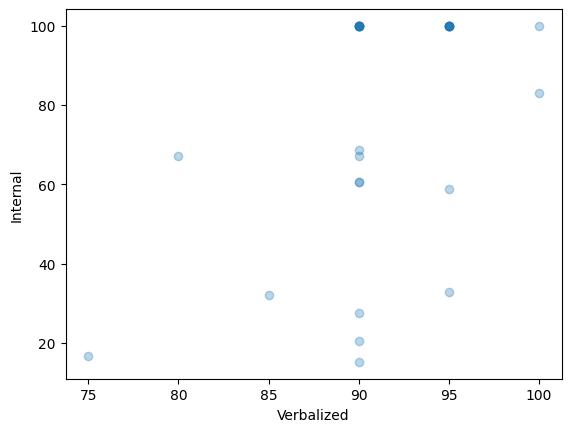

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = text_result["verb_confidence"].astype(float)
y = text_result["int_confidence"].astype(float)

plt.scatter(x, y, alpha=0.3)

plt.xlabel("Verbalized")
plt.ylabel("Internal")
plt.show()

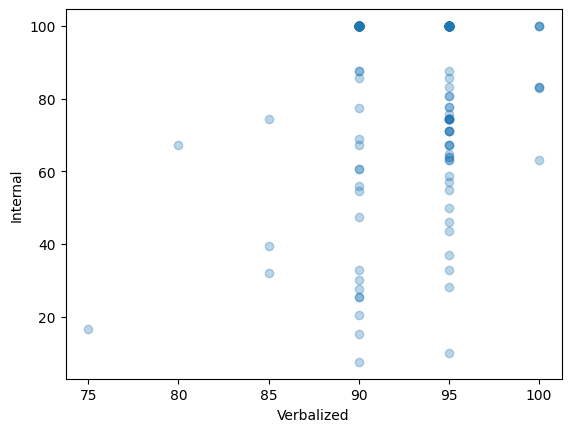

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(fd_data_clean["verb_confidence"], fd_data_clean["int_confidence"], alpha=0.3)
plt.xlabel("Verbalized")
plt.ylabel("Internal")
plt.show()

<Axes: ylabel='Frequency'>

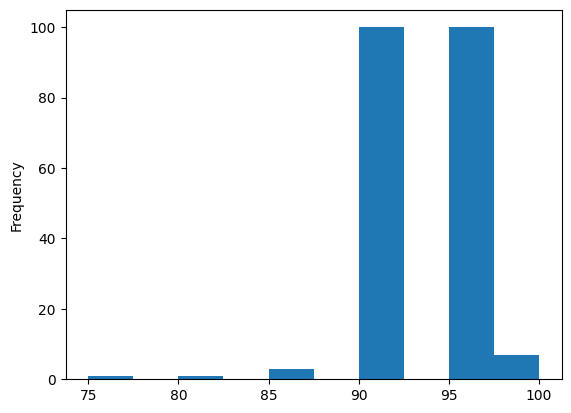

In [ ]:
fd_data_clean["verb_confidence"].plot(kind='hist')

<Axes: ylabel='Frequency'>

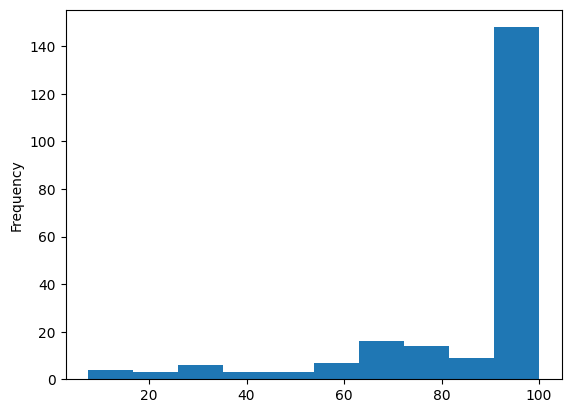

In [ ]:
fd_data_clean["int_confidence"].plot(kind='hist')